# Imports

In [ ]:
import os
import sys
sys.path.insert(0, "..")

import numpy as np
import random
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from transformers import get_linear_schedule_with_warmup
from sklearn.metrics import roc_curve, confusion_matrix, auc
from tqdm import tqdm

from classifiers import SAPClassifier, SPClassifier, MPClassifier
from pred_single_file import predict_file
from training_setup import build_loaders, build_loaders_v16, build_eval_loaders
from data_augmentation import laptop_mic
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score

In [2]:
def set_seed(seed: int = 42):
    # 1. Python random
    random.seed(seed)

    # 2. NumPy
    np.random.seed(seed)

    # 3. PyTorch (CPU)
    torch.manual_seed(seed)

    # 4. PyTorch (GPU)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

    # 5. Ensure deterministic behavior (IMPORTANT)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

    # 6. For extra reproducibility (optional but recommended)
    os.environ["PYTHONHASHSEED"] = str(seed)

    print(f"Seed set to {seed}")

In [3]:
set_seed(42)

Seed set to 42


# Config

In [ ]:
CONFIG = {
    # Paths
    "base_dir": "../dataset/asvspoof2019_LA",
    "wavefake_dir": "../dataset/WaveFake",
    "commonvoice_dir": "../dataset/commonvoice",
    "asvspoof2021_dir": "../dataset/asvspoof2021_DF",
    "in_the_wild_dir": "../dataset/in_the_wild",
    "checkpoint_dir": "checkpoints",
    "checkpoint_name": "best_model_SAP_v16d.pt",
    "model": SAPClassifier,

    "train_data": "commonvoice_wavefake",
    "commonvoice_max_samples": 5000,
    "wavefake_max_samples": 5000,

    # Backbone
    "backbone": "facebook/wav2vec2-base",
    "freeze_encoder": False,

    # Training hyperparameters
    "batch_size": 16,
    "max_epochs": 100,
    "patience": 7,

    # Optimiser
    "lr_classifier": 5e-5,
    "lr_encoder":    1e-6,
    "weight_decay":  0.05,
    "warmup_ratio":  0.1,
    "max_grad_norm": 1.0,

    # Loss — sampler balances bonafide/spoof at batch time
    "class_weights": [1.0, 1.0],

    # DataLoader
    "num_workers": 4,
}

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Training on: {device}")
print(f"GPU Name: {torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'N/A'}")
print(f"Backbone: {CONFIG['backbone']}  (frozen={CONFIG['freeze_encoder']})")
print(f"Train data: {CONFIG['train_data']}")
print(f"Checkpoint: {CONFIG['checkpoint_name']}")

Training on: cuda
GPU Name:   NVIDIA GeForce RTX 5080
Backbone:   facebook/wav2vec2-base  (frozen=False)
Train data: commonvoice_wavefake
Checkpoint: best_model_SAP_v16d.pt


# Helper Functions

In [ ]:
def compute_eer(labels, scores):
    """Computes the Equal Error Rate."""
    fpr, tpr, _ = roc_curve(labels, scores, pos_label=1)
    fnr = 1 - tpr
    idx = np.argmin(np.abs(fpr - fnr))
    return fpr, tpr, idx, (fpr[idx] + fnr[idx]) / 2

def compute_metrics(labels, scores, preds):
    _, _, eer_idx, eer = compute_eer(labels, scores)
    return {
        "eer": eer,
        "accuracy": accuracy_score(labels, preds),
        "f1": f1_score(labels, preds, average="weighted"),
        "precision": precision_score(labels, preds, average="weighted"),
        "recall": recall_score(labels, preds, average="weighted"),
    }

def run_inference(model, loader, device, loss_fn=None):
    """Runs inference and returns (labels, scores, preds) as numpy arrays."""
    model.eval()
    all_labels, all_scores, all_preds = [], [], []
    total_loss = 0

    with torch.no_grad():
        for batch in tqdm(loader, desc="Evaluating"):
            input_values = batch["input_values"].to(device)
            labels = batch["labels"].to(device)

            with torch.amp.autocast("cuda", dtype=torch.bfloat16):
                attention_mask = batch["attention_mask"].to(device)
                logits = model(input_values, attention_mask=attention_mask)
                if loss_fn is not None:
                    total_loss += loss_fn(logits, labels).item()

            probs = torch.softmax(logits.float(), dim=1)[:, 1]
            preds = torch.argmax(logits, dim=1)

            all_labels.extend(labels.cpu().numpy())
            all_scores.extend(probs.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    avg_loss = total_loss / len(loader) if loss_fn is not None else None
    return np.array(all_labels), np.array(all_scores), np.array(all_preds), avg_loss

def plot_results(labels, scores, preds):
    """Plots ROC curve and confusion matrix side-by-side."""
    metrics = compute_metrics(labels, scores, preds)
    fpr, tpr, eer_idx, eer = compute_eer(labels, scores)
    roc_auc = auc(fpr, tpr)

    print(f"\n--- Final Evaluation Results ---")
    print(f"EER: {metrics['eer'] * 100:.2f}%")
    print(f"Accuracy: {metrics['accuracy'] * 100:.2f}%")
    print(f"F1: {metrics['f1']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"AUC: {roc_auc:.4f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

    # ROC Curve
    ax1.plot(fpr, tpr, color="darkorange", lw=2, label=f"ROC curve (AUC = {roc_auc:.3f})")
    ax1.plot([0, 1], [0, 1], color="navy", lw=2, linestyle="--")
    ax1.plot(fpr[eer_idx], tpr[eer_idx], "ro", markersize=8, label=f"EER ({eer*100:.2f}%)")
    ax1.set(xlim=[0, 1], ylim=[0, 1.05], xlabel="False Positive Rate (Bonafide flagged as spoof)", ylabel="True Positive Rate (Spoof correctly detected)", title="Receiver Operating Characteristic (ROC)")
    ax1.legend(loc="lower right")
    ax1.grid(alpha=0.3)

    # Confusion Matrix
    cm = confusion_matrix(labels, preds)
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax2,
                xticklabels=["Bonafide (0)", "Spoof (1)"],
                yticklabels=["Bonafide (0)", "Spoof (1)"])
    ax2.set(xlabel="Predicted Label", ylabel="True Label", title="Confusion Matrix")

    plt.tight_layout()
    plt.show()

# Data, Model & Optimiser Setup

In [ ]:
# Datasets & DataLoaders
# WeightedRandomSampler balances bonafide/spoof — ~50/50 per batch.
# - v5 default (train_data unset or = "asvspoof_wavefake"): ASVspoof19 LA train + WaveFake, dev = ASVspoof19 LA dev.
# - v16 ("commonvoice_wavefake"): CV + WaveFake stratified-subsampled to ~5k each, dev = 10% stratified holdout.
transform = laptop_mic()

if CONFIG.get("train_data") == "commonvoice_wavefake":
    train_loader, dev_loader = build_loaders_v16(CONFIG, transform=transform)
else:
    train_loader, dev_loader = build_loaders(CONFIG, transform=transform)

CommonVoice: 5000 bonafide utterances across 5000 speakers
CommonVoice: 5000 bonafide utterances across 5000 speakers
WaveFake: 134266 spoof utterances loaded
WaveFake: 134266 spoof utterances loaded

v16 train — CommonVoice: 4500 bonafide | WaveFake: 4500 spoof | total 9000
v16 dev   — CommonVoice: 500 bonafide | WaveFake: 500 spoof | total 1000
Train batches/epoch: 563 (sampled 9000 from 9000 total)
Dev   batches:       63


In [ ]:
# Model
model = CONFIG["model"]().to(device)

# Optimiser with differential learning rates
optimizer = torch.optim.AdamW([
    {"params": model.encoder.parameters(), "lr": CONFIG["lr_encoder"]},
    {"params": model.pooling.parameters(), "lr": CONFIG["lr_classifier"]},
    {"params": model.classifier.parameters(), "lr": CONFIG["lr_classifier"]},
], weight_decay=CONFIG["weight_decay"])

# Scheduler
estimated_epochs = min(CONFIG["max_epochs"], 30)
total_steps = len(train_loader) * estimated_epochs
scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps=int(total_steps * CONFIG["warmup_ratio"]),
    num_training_steps=total_steps,
)

# Loss & mixed-precision scaler
class_weights = torch.tensor(CONFIG["class_weights"]).to(device)
loss_fn = nn.CrossEntropyLoss(weight=class_weights, label_smoothing=0.1)
scaler = torch.amp.GradScaler("cuda")

Initialising Self-Attention Pooling Classifier (backbone=facebook/wav2vec2-base)


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


# Training Loop

Evaluating: 100%|██████████| 63/63 [00:16<00:00,  3.91it/s]


Epoch 1 | Avg Loss: 0.3823 | Train Acc: 89.02% | Val Acc: 97.50% | Dev EER: 2.60%
  ⭐ New best EER — model saved.


Evaluating: 100%|██████████| 63/63 [00:05<00:00, 11.23it/s]


Epoch 2 | Avg Loss: 0.2242 | Train Acc: 99.08% | Val Acc: 98.50% | Dev EER: 0.70%
  ⭐ New best EER — model saved.


Evaluating: 100%|██████████| 63/63 [00:05<00:00, 11.56it/s]


...

Epoch 10 | Avg Loss: 0.2001 | Train Acc: 99.97% | Val Acc: 99.80% | Dev EER: 0.00%
  No improvement. Patience: 5/7


Evaluating: 100%|██████████| 63/63 [00:06<00:00,  9.23it/s]


Epoch 11 | Avg Loss: 0.1997 | Train Acc: 99.99% | Val Acc: 99.80% | Dev EER: 0.00%
  No improvement. Patience: 6/7


Evaluating: 100%|██████████| 63/63 [00:06<00:00,  9.24it/s]

Epoch 12 | Avg Loss: 0.1994 | Train Acc: 100.00% | Val Acc: 100.00% | Dev EER: 0.00%
  No improvement. Patience: 7/7
  🛑 Early stopping at epoch 12.


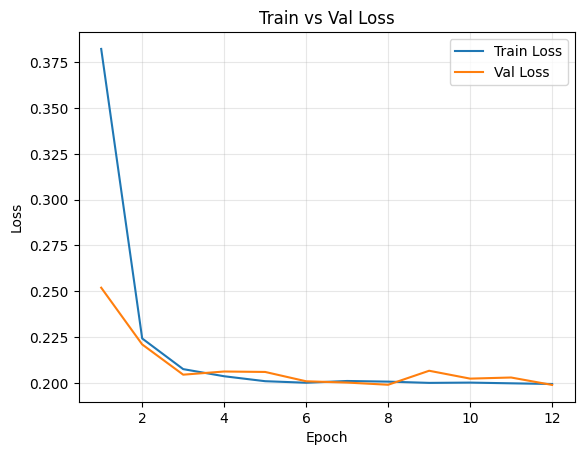

In [ ]:
os.makedirs(CONFIG["checkpoint_dir"], exist_ok=True)
checkpoint_path = os.path.join(CONFIG["checkpoint_dir"], CONFIG["checkpoint_name"])

best_eer = float("inf")
patience_counter = 0
history = {"train_loss": [], "val_loss": [], "train_acc": [], "val_acc": [], "val_eer": []}

for epoch in range(CONFIG["max_epochs"]):
    model.train()
    total_loss = 0
    correct, total = 0, 0

    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['max_epochs']}")
    for batch in pbar:
        input_values = batch["input_values"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda", dtype=torch.bfloat16):
            attention_mask = batch["attention_mask"].to(device)
            logits = model(input_values, attention_mask=attention_mask)
            loss = loss_fn(logits, labels)

        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), CONFIG["max_grad_norm"])
        scaler.step(optimizer)
        scaler.update()
        scheduler.step()

        total_loss += loss.item()
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)
        pbar.set_postfix({"loss": f"{loss.item():.4f}"})

    avg_loss = total_loss / len(train_loader)
    train_acc = correct / total
    history["train_acc"].append(train_acc)

    labels_dev, scores_dev, preds_dev, val_loss = run_inference(model, dev_loader, device, loss_fn=loss_fn)
    history["train_loss"].append(avg_loss)
    history["val_loss"].append(val_loss)
    dev_eer = compute_eer(labels_dev, scores_dev)[3]
    val_acc = accuracy_score(labels_dev, preds_dev)
    history["val_acc"].append(val_acc)
    history["val_eer"].append(dev_eer)

    print(f"Epoch {epoch+1} | Avg Loss: {avg_loss:.4f} | Train Acc: {train_acc*100:.2f}% | Val Acc: {val_acc*100:.2f}% | Dev EER: {dev_eer*100:.2f}%")

    if dev_eer < best_eer:
        best_eer = dev_eer
        patience_counter = 0
        torch.save(model.state_dict(), checkpoint_path)
        print(f"New best EER — model saved.")
    else:
        patience_counter += 1
        print(f"  No improvement. Patience: {patience_counter}/{CONFIG['patience']}")
        if patience_counter >= CONFIG["patience"]:
            print(f"Early stopping at epoch {epoch+1}.")
            break

# --- Plot training history ---
epochs = range(1, len(history["train_loss"]) + 1)
plt.plot(epochs, history["train_loss"], label="Train Loss")
plt.plot(epochs, history["val_loss"], label="Val Loss")
plt.xlabel("Epoch"); plt.ylabel("Loss")
plt.title("Train vs Val Loss"); plt.legend(); plt.grid(alpha=0.3)
plt.show()

# Evaluation on Eval Set

In [8]:
# Build all three eval loaders (clean, no augmentation)
# asvspoof19_eval  — in-domain
# asvspoof21_df    — cross-attack + codec
# in_the_wild      — held-out generalization
eval_loaders = build_eval_loaders(CONFIG)

Reading folder: ../dataset/asvspoof2019_LA\ASVspoof2019_LA_eval/flac
ASVspoof2021DF: 458871 utterances loaded (16977 bonafide, 441894 spoof)
InTheWild: 31779 utterances (19963 real, 11816 fake)
asvspoof19_eval: 71237 samples, 4453 batches
asvspoof21_df: 458871 samples, 28680 batches
in_the_wild: 31779 samples, 1987 batches


Loading checkpoint: checkpoints\best_model_SAP_v16.pt
Initialising Self-Attention Pooling Classifier (backbone=facebook/wav2vec2-base)


Loading weights:   0%|          | 0/211 [00:00<?, ?it/s]

Wav2Vec2Model LOAD REPORT from: facebook/wav2vec2-base
Key                          | Status     |  | 
-----------------------------+------------+--+-
quantizer.weight_proj.bias   | UNEXPECTED |  | 
project_hid.weight           | UNEXPECTED |  | 
quantizer.codevectors        | UNEXPECTED |  | 
quantizer.weight_proj.weight | UNEXPECTED |  | 
project_q.bias               | UNEXPECTED |  | 
project_hid.bias             | UNEXPECTED |  | 
project_q.weight             | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



  ASVspoof 2019 LA eval  (in-domain)


Evaluating: 100%|██████████| 4453/4453 [02:11<00:00, 33.76it/s]



--- Final Evaluation Results ---
EER:       33.14%
Accuracy:  47.23%
F1:        0.5538
Precision: 0.9015
Recall:    0.4723
AUC:       0.7306


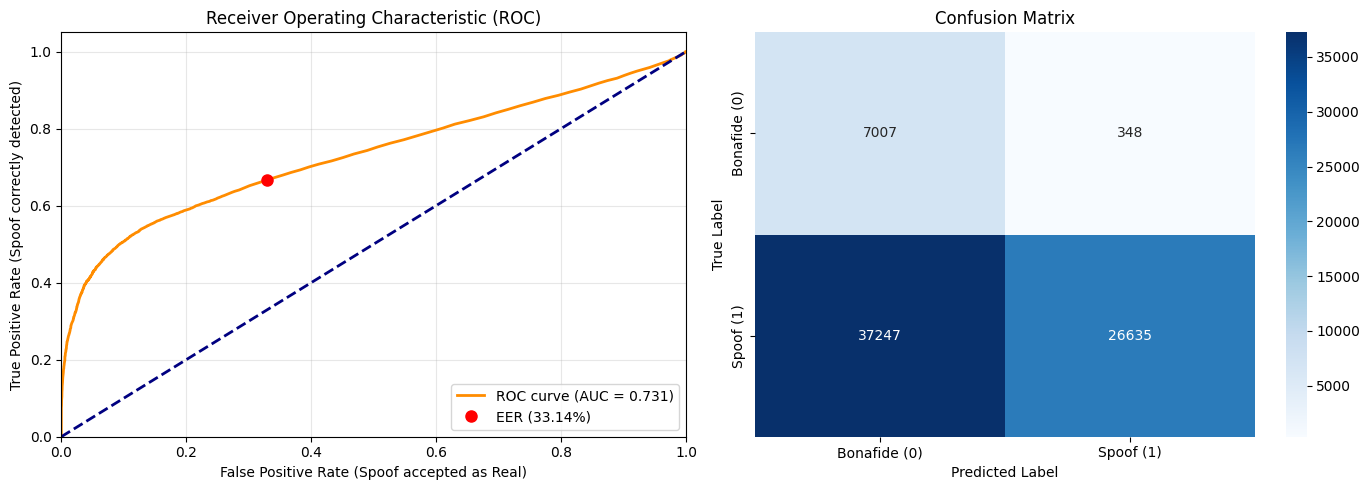


  ASVspoof 2021 DF eval  (cross-attack + codec)


Evaluating:   1%|          | 160/28680 [00:24<1:11:58,  6.60it/s]


KeyboardInterrupt: 

: 

In [ ]:
checkpoint_path = os.path.join(CONFIG["checkpoint_dir"], CONFIG["checkpoint_name"])
print(f"Loading checkpoint: {checkpoint_path}")
model = CONFIG["model"](model_name=CONFIG["backbone"]).to(device)
model.load_state_dict(torch.load(checkpoint_path, map_location=device))

eval_names = {
    "asvspoof19_eval": "ASVspoof 2019 LA eval  (in-domain)",
    "asvspoof21_df":   "ASVspoof 2021 DF eval  (cross-attack + codec)",
    "in_the_wild":     "In-the-Wild            (held-out generalization)",
}

for key, loader in eval_loaders.items():
    print(f"\n{'='*55}")
    print(f"  {eval_names[key]}")
    print(f"{'='*55}")
    labels, scores, preds, _ = run_inference(model, loader, device)
    plot_results(labels, scores, preds)